In [34]:
from utils.image_helper import noise_level_estimation, load_vi_image_from_hdf5
from utils.utilities import get_observation, get_correct_filepath
import numpy as np
import os

import resolve as rve

import matplotlib.pyplot as plt

import h5py

from matplotlib.gridspec import GridSpec

import pickle

In this notebook some examples for visualization of resolve results are provided.

Here is how you can load the data into resolve, after running the imaging (so that the uvf file is transformed already into ms format):

In [2]:
source = "3C120"
datafile = "0430+052.u.2001_02_01.uvf_raw_edt.gz"

obs = get_observation("./ms_data", source, datafile)

Work on Field 0: 3C120
Work on Field 0: 3C120
Work on Field 0: 3C120
Work on Field 0: 3C120


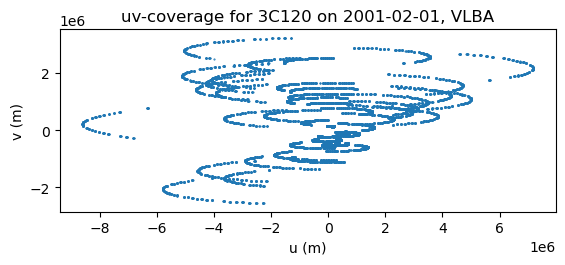

In [28]:
# You can use the loaded data to create different kinds of plots

plt.plot(obs.uvw[:, 0], obs.uvw[:, 1], '.', markersize=1)
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.title(f"uv-coverage for {source} on 2001-02-01, VLBA")
plt.gca().set_aspect('equal')

Let's plot the results:

In [38]:
def get_chi_2(source, dir_name, seed):
    """Load the chi-squared history from the pickle file and return the final value of the mean chi-squared for the data residuals.
    Divide by 2, since the data visibilities are complex. 

    Parameters:
    --------------
    source : str
        The name of the source.
    dir_name : str
        The name of the directory where the results are stored.
    seed : int
        The seed number of the run.

    """
    pickle_path = f"./results/output_files/{source}/{dir_name}/seed_{seed}/pickle/minisanity_history_last"
    with open(pickle_path, mode='rb') as f:
        data = pickle.load(f)
    
    results_dict = data["redchisq"]['data_residuals']
    keys_list = list(results_dict.keys())
    return results_dict[keys_list[0]]['mean'][-1] / 2



def plot_source(source, dir_name, seed, title, vmin=None, vmax=None, xlim=None, ylim=None, contours=False, n_contours=5, colormap='inferno') -> None:
    """Plot the image of a source. Allows for custom color scale limits, axis limits, and contour overlay.

    Parameters:
    --------------
    source : str
        The name of the source to plot.
    dir_name : str
        The name of the directory where the results are stored.
    seed : int
        The seed number of the run to plot.
    title : str
        The title to display on the plot.
    vmin : float, optional
        The minimum value for the color scale (in log10). If None, it will be set to the log10 of the estimated noise level.
    vmax : float, optional
        The maximum value for the color scale (in log10). If None, it will be set to the log10 of the maximum pixel value in the image.
    xlim : tuple, optional
        The limits for the x-axis (RA) in mas. If None, it will be set to the full field of view.
    ylim : tuple, optional
        The limits for the y-axis (Dec) in mas. If None, it will be set to the full field of view.
    contours : bool, optional
        Whether to overlay contour lines on the image. Default is False.
    n_contours : int, optional
        The number of contour levels to plot if contours is True. Default is 5.
    colormap : str, optional
        The colormap to use for the image. Default is 'inferno'.
    """


    path = f"./results/output_files/{source}/{dir_name}/seed_{seed}/sky/"
    image = load_vi_image_from_hdf5(get_correct_filepath(path))

    chi2_val = get_chi_2(source, dir_name, seed)

    nx, ny = image.shape
    fovx, fovy = nx * 0.05, ny * 0.05  # in mas

    x = np.linspace(+fovx / 2, -fovx / 2, nx)  # RA plotted reversed
    y = np.linspace(-fovy / 2, +fovy / 2, ny)
    X, Y = np.meshgrid(x, y)

    noise_level = noise_level_estimation(image)

    vmin = np.log10(noise_level) if vmin is None else vmin
    vmax = np.log10(image.max()) if vmax is None else vmax
    fig = plt.figure()

    # Here transpose the image to match the orientation of the axes, as resolve stores them in (nx, ny) order but pcolormesh expects (ny, nx) order
    im = plt.pcolormesh(X, Y, np.log10(image).T, vmin=vmin, vmax=vmax, shading='auto', cmap=colormap)
    pos_levels = np.linspace(vmin, vmax, n_contours)[1:]  # Exclude the lowest level to avoid plotting noise contours
    if contours:
        plt.contour(X, Y, np.log10(image).T, levels=pos_levels, colors='white', linewidths=0.8)

    plt.title(f'{title}, $\\chi^2_{{\\text{{red}}}} = {chi2_val:.2f}$', fontsize=14)
    plt.colorbar(im, ax=plt.gca(), label=r"$\log_{10}[I \ (\text{Jy/mas}^2)]$")
    plt.xlabel('Relative RA (mas)')
    plt.ylabel('Relative Dec (mas)')

    plt.gca().invert_xaxis()

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.gca().set_aspect('equal')

    plt.show()
    plt.close(fig)


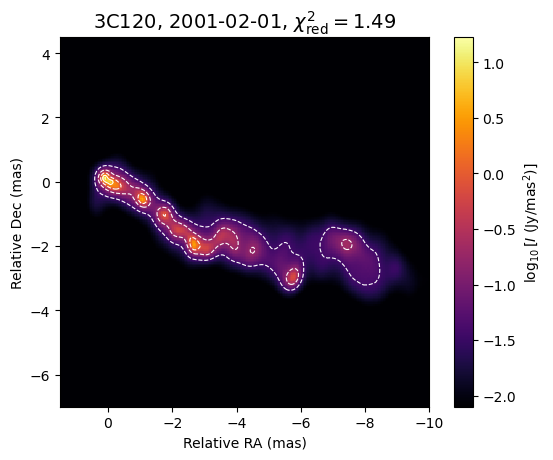

In [39]:
# dir_name is specified when starting the run. If not specified, it would be the same as the name of the datafile
dir_name = "2001_02_01" 
title = "3C120, 2001-02-01"
seed = 740

plot_source(source, dir_name, seed=seed, title=title, contours=True, n_contours=6, vmin=-2.1, xlim=(1.5, -10), ylim=(-7, 4.5))

Now let's use the fact that our method is Bayesian and plot uncertainty maps. As we have multiple image samples, we can calculate per-pixel std and display it.

In [40]:
def load_samples(hdf5_file):
    with h5py.File(hdf5_file, 'r') as hdf:
        samples_data = np.array([hdf['samples'][f"{i}"] for i in range(len(hdf['samples']))])[:, 0, 0, 0, :, :]

    # resolve stores pixel values in Jy/sr, so we need to convert to Jy/mas^2 for plotting
    return samples_data / (206265 ** 2 * 1000 ** 2)


def uncertainty_map(source_name, dir_name, seed, title, pixscale=0.05, 
                        xlim=None, ylim=None, colormap='inferno') -> None:
    """
    Create uncertainty maps with 2 subplots:
    [0,0] Absolute Uncertainty (per-pixel std), [0,1] Relative Uncertainty (per-pixel std / mean image)


    Parameters:
    --------------
    source_name : str
        The name of the source to plot.
    dir_name : str
        The name of the directory where the results are stored.
    seed : int
        The seed number of the run to plot.
    title : str
        The title to display on the plot.
    pixscale : float, optional
        The pixel scale in mas/pixel. Default is 0.05 mas/pixel.
    xlim : tuple, optional
        The limits for the x-axis (RA) in mas. If None, it will be set to the full field of view.
    ylim : tuple, optional
        The limits for the y-axis (Dec) in mas. If None, it will be set to the full field of view.
    colormap : str, optional
        The colormap to use for the images. Default is 'inferno'.
    """


    vi_hdf5 = f"./results/output_files/{source_name}/{dir_name}/seed_{seed}/sky"

    samples = load_samples(get_correct_filepath(vi_hdf5))
    mean_image = np.mean(samples, axis=0).T
    std_image = np.std(samples, axis=0).T

    nx, ny = mean_image.shape
    fovx, fovy = nx * pixscale, ny * pixscale  # in mas
    min_x, max_x = -fovx / 2, fovx / 2
    min_y, max_y = -fovy / 2, fovy / 2


    fig = plt.figure(figsize=(16, 7))
    gs = GridSpec(1, 2, figure=fig, wspace=0.24)

    # ===== TOP LEFT: ABSOLUTE UNCERTAINTY IMAGE =====
    abs_ax = fig.add_subplot(gs[0, 0])

    x = np.linspace(+fovx / 2, -fovx / 2, nx)  # RA plotted reversed
    y = np.linspace(-fovy / 2, +fovy / 2, ny)
    X, Y = np.meshgrid(x, y)
    
    im = abs_ax.pcolormesh(X, Y, np.log10(std_image), shading='auto', cmap=colormap)
    abs_ax.set_title(f'Absolute uncertainty', fontsize=20, fontweight='bold')
    plt.colorbar(im, ax=abs_ax, label=r"$\log_{10}[\delta I \ (\text{Jy/mas}^2)]$")
    abs_ax.invert_xaxis()

    if xlim is not None:
        abs_ax.set_xlim(xlim)
    if ylim is not None:
        abs_ax.set_ylim(ylim)

    abs_ax.set_aspect('equal')
    abs_ax.set_xlabel("Relative RA (mas)")
    abs_ax.set_ylabel("Relative Dec (mas)")



    # ===== TOP RIGHT: RELATIVE UNCERTAINTY IMAGE =====
    rel_ax = fig.add_subplot(gs[0, 1])

    rel_uncertainty = std_image / mean_image

    im = rel_ax.pcolormesh(X, Y, np.log10(rel_uncertainty), shading='auto', cmap=colormap)
    rel_ax.set_title('Relative uncertainty', fontsize=20, fontweight='bold')
    rel_ax.set_xlim(max_x, min_x)
    rel_ax.set_ylim(min_y, max_y)
    
    fig.colorbar(im, ax=rel_ax, label=r"$\log_{10}[\delta I / I]$")
    
    if xlim is not None:
        rel_ax.set_xlim(xlim)
    
    if ylim is not None:
        rel_ax.set_ylim(ylim)
        
    rel_ax.set_aspect('equal')
    rel_ax.set_xlabel("Relative RA (mas)")
    rel_ax.set_ylabel("Relative Dec (mas)")

    fig.suptitle(f'{title}', fontsize=16, fontweight='bold', y=0.995)

    
    plt.show()
    plt.close(fig)


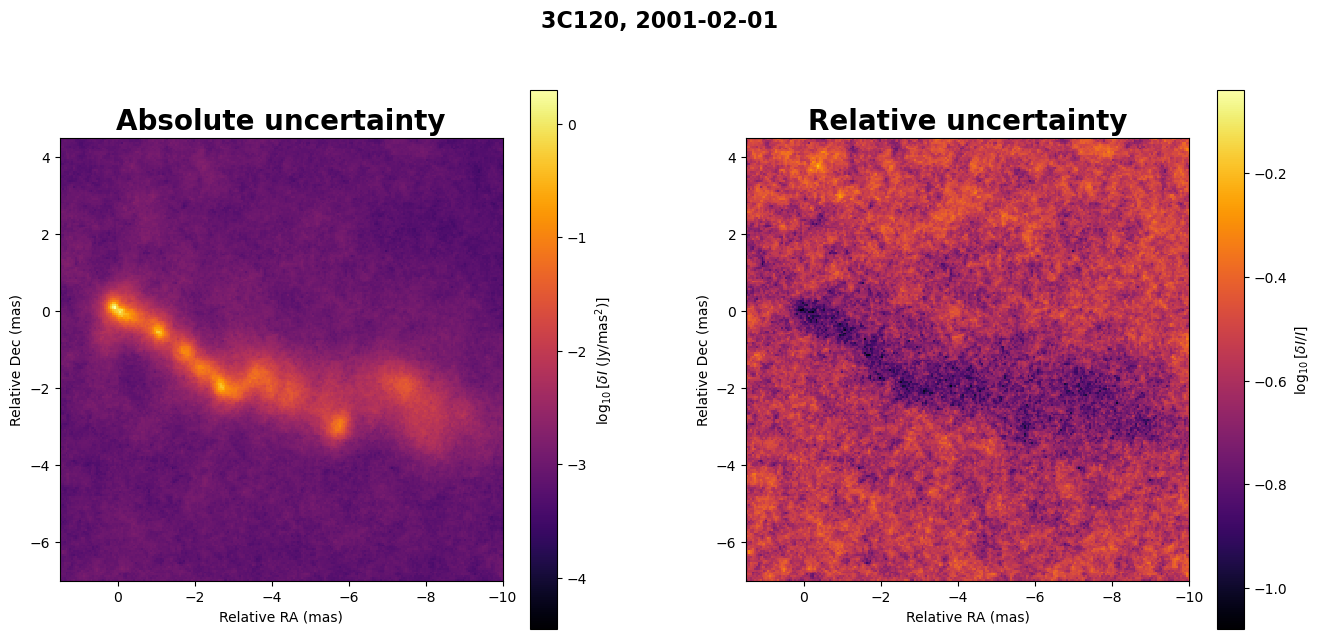

In [41]:
uncertainty_map(source_name=source, dir_name=dir_name, seed=seed, title=title, xlim=(1.5, -10), ylim=(-7, 4.5))

We can also plot the inferred gains:

In [42]:
def create_gain_plots(obs, source, dir_name, seed, title):
    """Show gain plots, one for amplitude and one for phases.
    
    Parameters:
    --------------
    obs : resolve.Observation
        The observation object containing the data and metadata.
    source : str
        The name of the source being analyzed.
    dir_name : str
        The name of the directory where the results are stored.
    seed : int
        The seed number of the run to plot.
    title : str
        The title to display on the plots.
    """
    uantennas = rve.unique_antennas(obs)
    station_table = obs._auxiliary_tables["ANTENNA"]["STATION"]

    time = obs.time - obs.time[0]
    
    single_gain = obs.vis.val.shape[0] == 1

    base_path = f"./results/output_files/{source}/{dir_name}/seed_{seed}/gain_logamp"
    gain_filename = get_correct_filepath(base_path)

    with h5py.File(gain_filename, "r") as hdf:
        amp_samples_list = []

        for ii in np.arange(np.array(hdf["samples"]).size):
            amp_sample = np.exp(np.array(hdf["samples"][f"{ii}"]))
            amp_samples_list.append(amp_sample)

        amp_samples_mean = np.mean(amp_samples_list, axis=0)
        amp_samples_std = np.std(amp_samples_list, axis=0)

        N = amp_samples_mean.shape[2]
        T = 10
        time_domain = np.linspace(0, N * T, N, endpoint=False)
        time_domain_hours = time_domain / 3600
        half_n_amp = len(time_domain_hours) // 2
        time_domain_hours_half_amp = time_domain_hours[:half_n_amp]

    base_phase_path = f"./results/output_files/{source}/{dir_name}/seed_{seed}/gain_phase"
    phase_filename = get_correct_filepath(base_phase_path)

    with h5py.File(phase_filename, "r") as hdf:
        phase_samples_list = []

        for ii in np.arange(np.array(hdf["samples"]).size):
            phase_sample = np.array(hdf["samples"][f"{ii}"])
            phase_samples_list.append(phase_sample)

        phase_samples_mean = np.mean(phase_samples_list, axis=0)
        phase_samples_mean_deg = 180 / np.pi * phase_samples_mean

        phase_samples_std = np.std(phase_samples_list, axis=0)
        phase_samples_std_deg = 180 / np.pi * phase_samples_std

        N = phase_samples_mean.shape[2]
        T = 10
        time_domain = np.linspace(0, N * T, N, endpoint=False)
        time_domain_hours = time_domain / 3600
        half_n_phase = len(time_domain_hours) // 2
        time_domain_hours_half_phase = time_domain_hours[:half_n_phase]

    n_antennas = len(uantennas)
    amp_cols = 1 if single_gain else 2
    phase_cols = amp_cols

    fig_amp, axs_amp = plt.subplots(
        nrows=n_antennas,
        ncols=amp_cols,
        figsize=(6 * amp_cols, 2.2 * n_antennas),
        sharex=True,
        sharey=True,
    )
    fig_phase, axs_phase = plt.subplots(
        nrows=n_antennas,
        ncols=phase_cols,
        figsize=(6 * phase_cols, 2.2 * n_antennas),
        sharex=True,
        sharey=True,
    )

    def _normalize_axes(axs, nrows, ncols):
        if nrows == 1 and ncols == 1:
            return np.array([[axs]])
        if nrows == 1:
            return np.array([axs])
        if ncols == 1:
            return np.array([[ax] for ax in axs])
        return axs

    axs_amp = _normalize_axes(axs_amp, n_antennas, amp_cols)
    axs_phase = _normalize_axes(axs_phase, n_antennas, phase_cols)

    def _apply_time_breaks(axs, antenna):
        time_antenna = time[(obs.ant1 == antenna) | (obs.ant2 == antenna)]
        dt = np.diff(time_antenna)
        breaks = np.where(dt > 5 * np.median(dt))[0]

        starts = np.r_[0, breaks + 1]
        ends = np.r_[breaks, len(time_antenna) - 1]

        for ax in axs:
            for s, e in zip(starts, ends):
                ax.axvspan(time_antenna[s] / 3600, time_antenna[e] / 3600, color="0.85", alpha=0.7, zorder=0)

    amp_values = amp_samples_mean[:, :, :half_n_amp, 0]
    amp_std_values = amp_samples_std[:, :, :half_n_amp, 0]
    amp_min = np.min(amp_values - amp_std_values)
    amp_max = np.max(amp_values + amp_std_values)
    amp_pad = 0.05 * (amp_max - amp_min) if amp_max > amp_min else 1.0
    amp_ylim = (amp_min - amp_pad, amp_max + amp_pad)

    phase_values = phase_samples_mean_deg[:, :, :half_n_phase, 0]
    phase_std_values = phase_samples_std_deg[:, :, :half_n_phase, 0]
    phase_min = np.min(phase_values - phase_std_values)
    phase_max = np.max(phase_values + phase_std_values)
    phase_pad = 0.05 * (phase_max - phase_min) if phase_max > phase_min else 1.0
    phase_ylim = (phase_min - phase_pad, phase_max + phase_pad)

    for ii, antenna in enumerate(uantennas):
        station = station_table[antenna]
        print(f"Processing antenna {station}")
        _apply_time_breaks([axs_amp[ii, 0], axs_phase[ii, 0]], antenna)
        if not single_gain:
            _apply_time_breaks([axs_amp[ii, 1], axs_phase[ii, 1]], antenna)

        amp_lcp_mean = amp_samples_mean[0, ii, :half_n_amp, 0]
        amp_lcp_std = amp_samples_std[0, ii, :half_n_amp, 0]
        ax_amp_lcp = axs_amp[ii, 0]
        ax_amp_lcp.plot(time_domain_hours_half_amp, amp_lcp_mean, linewidth=1.0)
        ax_amp_lcp.fill_between(
            time_domain_hours_half_amp,
            amp_lcp_mean - amp_lcp_std,
            amp_lcp_mean + amp_lcp_std,
            alpha=0.5,
        )
        ax_amp_lcp.set_ylabel(station)

        if not single_gain:
            amp_rcp_mean = amp_samples_mean[1, ii, :half_n_amp, 0]
            amp_rcp_std = amp_samples_std[1, ii, :half_n_amp, 0]
            ax_amp_rcp = axs_amp[ii, 1]
            ax_amp_rcp.plot(time_domain_hours_half_amp, amp_rcp_mean, linewidth=1.0)
            ax_amp_rcp.fill_between(
                time_domain_hours_half_amp,
                amp_rcp_mean - amp_rcp_std,
                amp_rcp_mean + amp_rcp_std,
                alpha=0.5,
            )

        phase_lcp_mean = phase_samples_mean_deg[0, ii, :half_n_phase, 0]
        phase_lcp_std = phase_samples_std_deg[0, ii, :half_n_phase, 0]
        ax_phase_lcp = axs_phase[ii, 0]
        ax_phase_lcp.plot(time_domain_hours_half_phase, phase_lcp_mean, linewidth=1.0)
        ax_phase_lcp.fill_between(
            time_domain_hours_half_phase,
            phase_lcp_mean - phase_lcp_std,
            phase_lcp_mean + phase_lcp_std,
            alpha=0.5,
        )
        ax_phase_lcp.set_ylabel(station)

        if not single_gain:
            phase_rcp_mean = phase_samples_mean_deg[1, ii, :half_n_phase, 0]
            phase_rcp_std = phase_samples_std_deg[1, ii, :half_n_phase, 0]
            ax_phase_rcp = axs_phase[ii, 1]
            ax_phase_rcp.plot(time_domain_hours_half_phase, phase_rcp_mean, linewidth=1.0)
            ax_phase_rcp.fill_between(
                time_domain_hours_half_phase,
                phase_rcp_mean - phase_rcp_std,
                phase_rcp_mean + phase_rcp_std,
                alpha=0.5,
            )

    for ax in axs_amp.ravel():
        ax.set_ylim(amp_ylim)

    for ax in axs_phase.ravel():
        ax.set_ylim(phase_ylim)

    if single_gain:
        axs_amp[0, 0].set_title("Amplitude gain")
        axs_phase[0, 0].set_title("Phase gain")
    else:
        axs_amp[0, 0].set_title("Amplitude gain LCP")
        axs_amp[0, 1].set_title("Amplitude gain RCP")
        axs_phase[0, 0].set_title("Phase gain LCP")
        axs_phase[0, 1].set_title("Phase gain RCP")

    fig_amp.supxlabel("Relative time, hours")
    fig_amp.supylabel("Amplitude gain")
    fig_amp.suptitle(f"{title} - Amplitude gains", fontsize=16)
    fig_amp.tight_layout(rect=[0.04, 0.04, 1, 0.95])

    fig_phase.supxlabel("Relative time, hours")
    fig_phase.supylabel("Phase gain, deg")
    fig_phase.suptitle(f"{title} - Phase gains", fontsize=16)
    fig_phase.tight_layout(rect=[0.04, 0.04, 1, 0.95])

    plt.show()

    plt.close(fig_amp)
    plt.close(fig_phase)


Processing antenna BR
Processing antenna FD
Processing antenna HN
Processing antenna KP
Processing antenna LA
Processing antenna MK
Processing antenna NL
Processing antenna OV
Processing antenna PT
Processing antenna SC


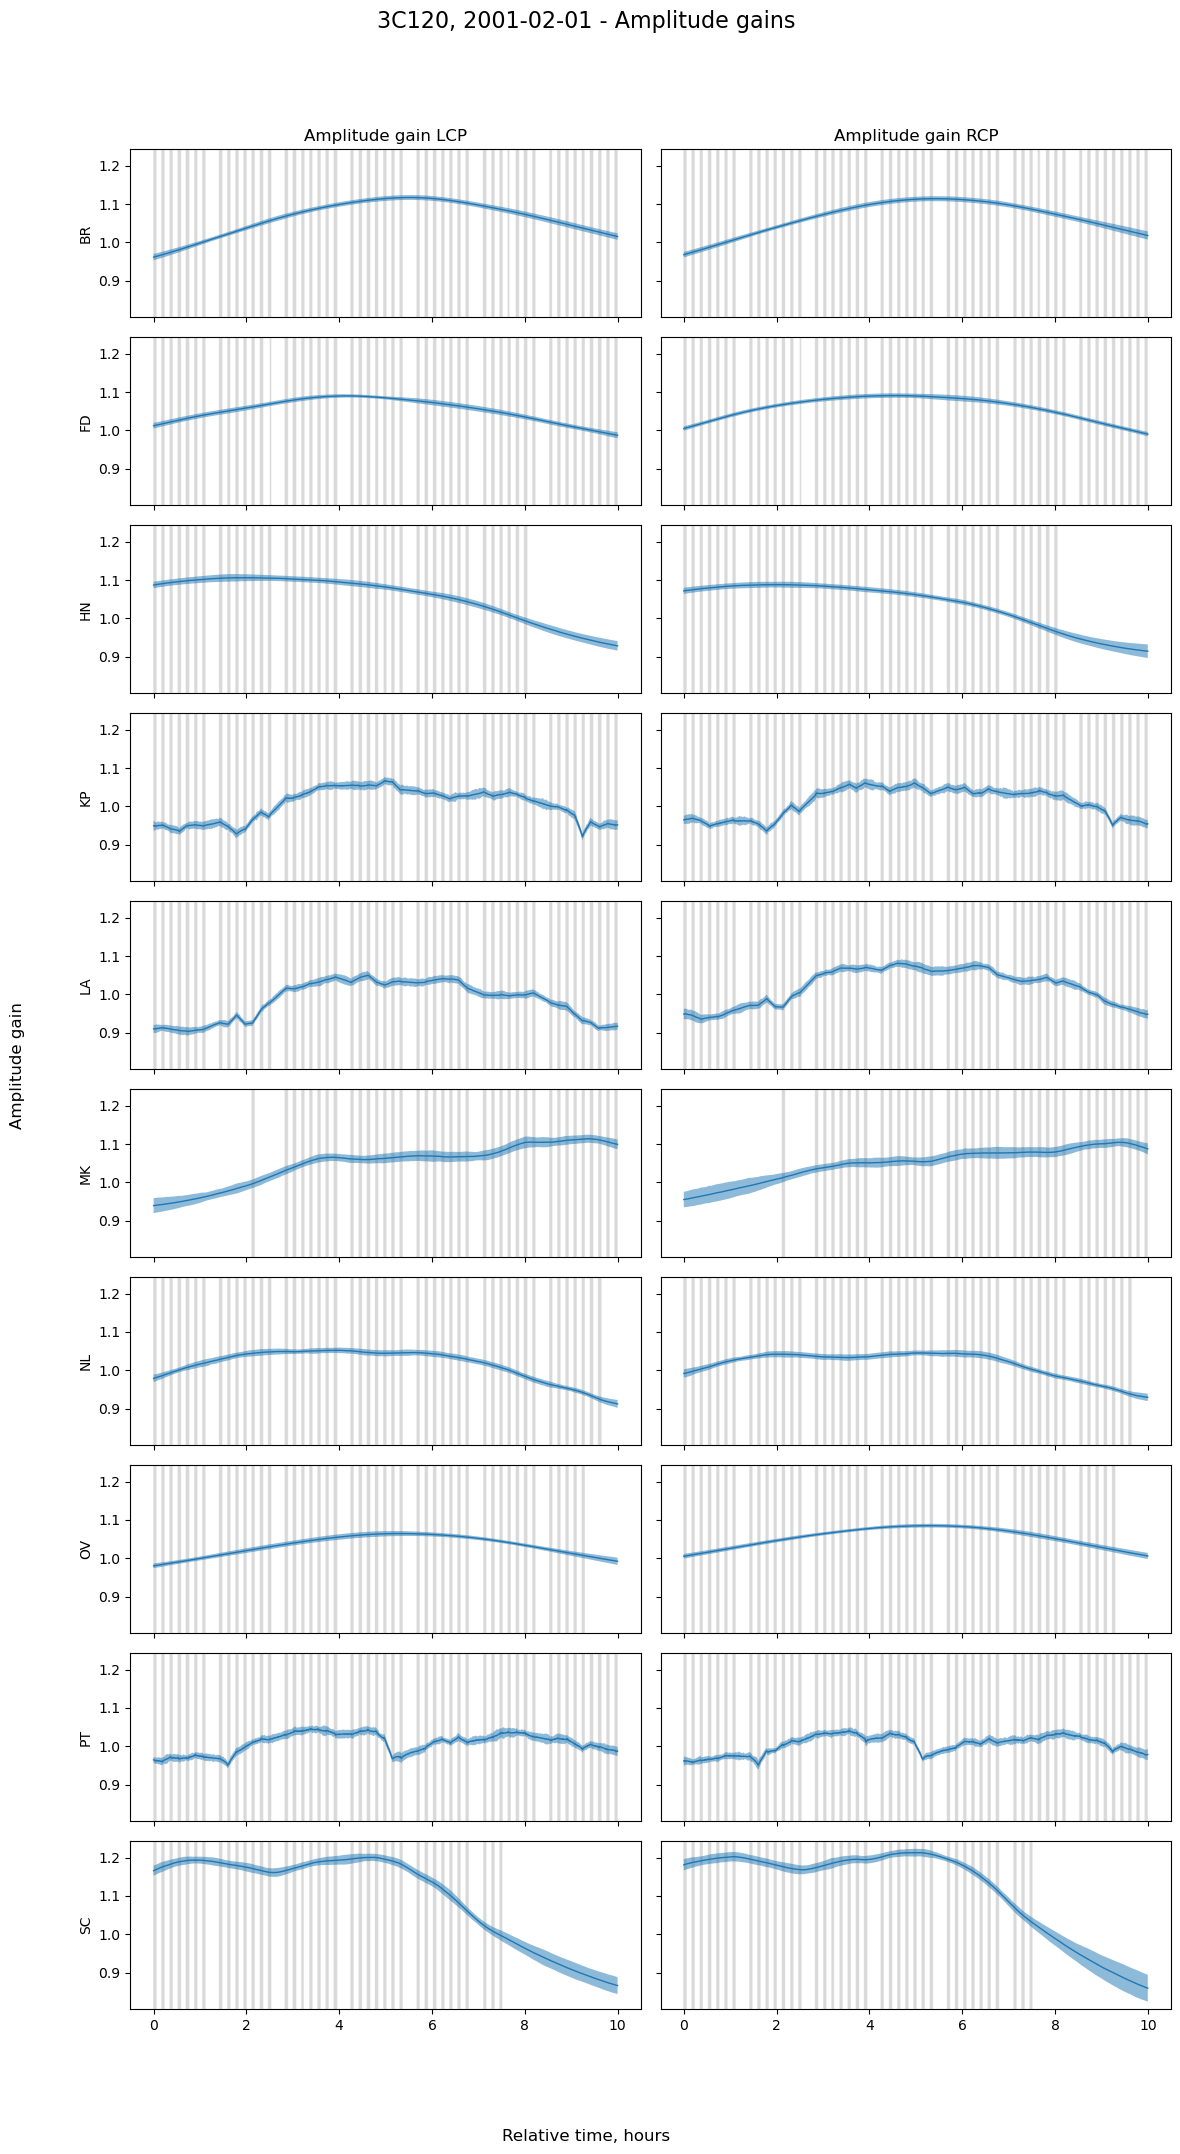

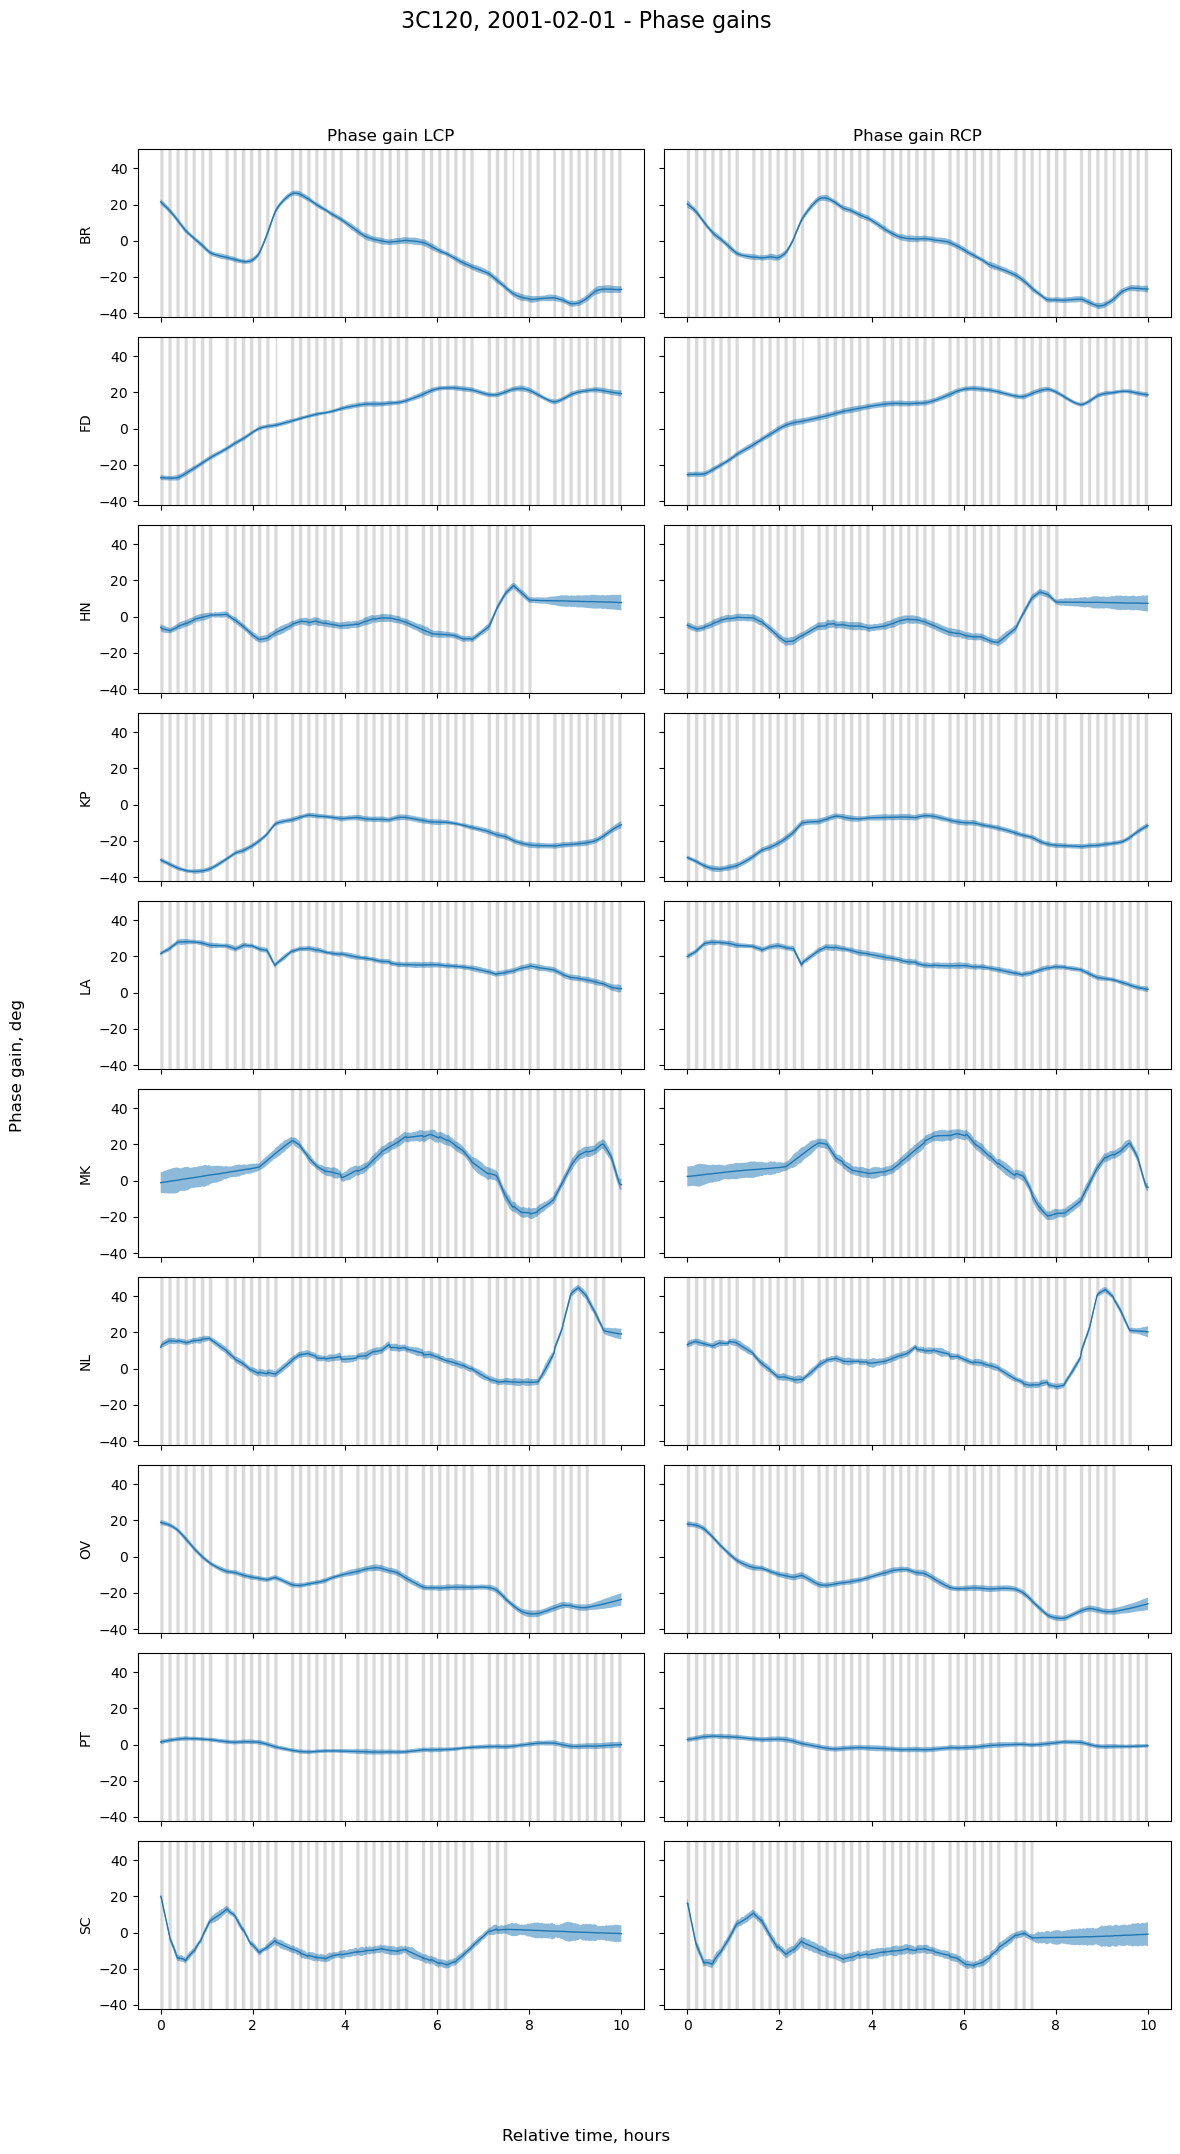

In [33]:
create_gain_plots(obs, source, dir_name, seed, title)